# Analisis Transaksi Penjualan iPhone


> Final Project Data Analyst

1. Latar Belakang
iPhone merupakan salah satu produk smartphone premium dengan tingkat penjualan tinggi di Indonesia. Untuk mendukung strategi bisnis berbasis data, perusahaan perlu memahami lebih dalam pola pembelian pelanggan, mulai dari perilaku pembelian, usia, segmentasi pelanggan, respons terhadap diskon, hingga perbedaan pola pembelian antar kota. Analisis ini bertujuan untuk membantu pengambilan keputusan strategis dalam hal pemasaran dan retensi pelanggan.

2. Tujuan
- Membersihkan dan mempersiapkan dataset agar siap dianalisis.
- Mengidentifikasi tren penjualan berdasarkan waktu, usia, dan lokasi pelanggan.
- Mengelompokkan pelanggan ke dalam segmen berdasarkan perilaku pembelian.
- Menganalisis pengaruh diskon terhadap pola pembelian.
- Memberikan insight untuk strategi pemasaran dan pengelolaan relasi pelanggan.


3. Dataset
- transactions.csv – Data transaksi utama
- transaction_details.csv – Detail produk di tiap transaksi
- products.csv – Informasi spesifikasi produk
- customers.csv – Informasi pelanggan





In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/My Drive/FINAL PROJECT DATA ANALYST/DATA MENTAH/'
folder_path1 = '/content/drive/My Drive/FINAL PROJECT DATA ANALYST/DATA FINAL/BEFORE CLEANING/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Tahapan Analisis


## Persiapan dan Import Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
# Load files
df_transactions = pd.read_csv(folder_path + 'transactions.csv')
df_transaction_details = pd.read_csv(folder_path + 'transaction_details.csv')
df_products = pd.read_csv(folder_path + 'products.csv')
df_customers = pd.read_csv(folder_path + 'customers.csv')

# tampilkan 5 data pertama
df_transactions.head()

,transaction_id,customer_id,transaction_date,total_amount,payment_method,shipping_method,delivery_time,coupon_code,city,product_id,sales_factor
0,1,506,2023-07-22,11300000.0,Cash on Delivery,Tiki,1 minggu,GRATISONGKIR,Jakarta,12,0.7
1,2,23275,2024-07-01,11053000.0,DANA,Tiki,2-3 hari,SALE20,Bandung,3,0.9
2,3,24101,2022-11-01,12741000.0,Transfer Bank,JNE,4-5 hari,NaN,Bandung,5,0.8
3,4,24188,2022-02-04,4921000.0,OVO,JNE,4-5 hari,SALE20,Yogyakarta,10,0.6
4,5,33766,2022-02-06,2163000.0,Transfer Bank,GrabExpress,1 minggu,NaN,Jakarta,11,0.7


In [ ]:
df_transaction_details.head()

,transaction_id,product_id,quantity,unit_price,discount,total
0,25218,12,3,7000000,15,17850000.0
1,78866,9,1,15000000,15,12750000.0
2,71024,1,3,11000000,15,28050000.0
3,45980,6,4,12000000,15,40800000.0
4,35845,4,3,17000000,15,43350000.0


In [ ]:
df_customers.head()

,customer_id,name,email,address,phone_number,age,city,preferred_product_id
0,1,Pranata Natsir,marsudimaryati@example.net,"Gang K.H. Wahid Hasyim No. 2\nProbolinggo, Sul...",(049) 526-4376,28,Medan,4
1,2,Estiono Irawan,cagak03@example.net,"Gg. KH Amin Jasuta No. 934\nTernate, BB 16278",+62-0135-866-6997,46,Medan,4
2,3,Yessi Yulianti,karimahhabibi@example.org,"Gg. Cihampelas No. 1\nCilegon, Jambi 06207",+62-099-515-6369,58,Makassar,2
3,4,drg. Bakti Kusmawati,ipertiwi@example.com,Jl. M.T Haryono No. 67\nKota Administrasi Jaka...,+62 (898) 893-0434,59,Bandung,9
4,5,Martani Sihombing,alazuardi@example.org,"Jl. Moch. Toha No. 2\nSabang, SB 34581",+62 (045) 241 9670,51,Bandung,3


In [ ]:
df_customers["city"].unique()

array(['Medan', 'Makassar', 'Bandung', 'Jakarta', 'Surabaya', 'Denpasar',
       'Yogyakarta'], dtype=object)

In [ ]:
df_products

,product_id,product_name,category,brand,price,description,discount,storage,color,release_year,years_since_release,sales_factor,preferred_product_id
0,1,iPhone 15,Smartphone,Apple,12000000,Accusantium enim inventore optio eum quam atque.,15,128GB,Black,2023,1,0.9,1
1,2,iPhone 15 Plus,Smartphone,Apple,13000000,Quisquam officiis eaque iste quidem voluptate ...,15,256GB,Blue,2023,1,0.9,2
2,3,iPhone 15 Pro,Smartphone,Apple,16000000,Necessitatibus blanditiis veritatis quibusdam.,10,512GB,Silver,2023,1,0.9,3
3,4,iPhone 15 Pro Max,Smartphone,Apple,18000000,Perspiciatis omnis minus.,5,1TB,Gold,2023,1,0.9,4
4,5,iPhone 14,Smartphone,Apple,11000000,Adipisci unde excepturi placeat saepe iusto.,15,128GB,Red,2022,2,0.8,5
5,6,iPhone 14 Plus,Smartphone,Apple,12000000,Dicta aut doloremque perferendis dolor aut dolor.,5,256GB,Green,2022,2,0.8,6
6,7,iPhone 14 Pro,Smartphone,Apple,15000000,Veritatis quam nemo provident id.,5,512GB,Purple,2022,2,0.8,7
7,8,iPhone 14 Pro Max,Smartphone,Apple,17000000,Veritatis perferendis magnam velit.,0,128GB,Yellow,2022,2,0.8,8
8,9,iPhone SE (3rd Gen),Smartphone,Apple,7000000,Minima iusto laudantium vitae ipsam amet.,5,64GB,White,2021,3,0.5,9
9,10,iPhone 13,Smartphone,Apple,10000000,Quasi repellat dolor aliquid incidunt sed fugi...,15,128GB,Pink,2021,3,0.6,10


In [ ]:
print("products:", df_products.columns.tolist())

products: ['product_id', 'product_name', 'category', 'brand', 'price', 'description', 'discount', 'storage', 'color', 'release_year', 'years_since_release', 'sales_factor', 'preferred_product_id']


## Penggabungan Dataset

In [ ]:
# Merge transaction_details + products
merged = pd.merge(df_transaction_details, df_products, on='product_id', how='left')

# Merge hasilnya dengan transactions
merged = pd.merge(merged, df_transactions, on='transaction_id', how='left')

# Merge hasilnya dengan customers (via customer_id dari transactions)
merged = pd.merge(merged, df_customers, on='customer_id', how='left')

In [ ]:
print("Merged columns:\n", merged.columns.tolist())

Merged columns:
 ['transaction_id', 'product_id_x', 'quantity', 'unit_price', 'discount_x', 'total', 'product_name', 'category', 'brand', 'price', 'description', 'discount_y', 'storage', 'color', 'release_year', 'years_since_release', 'sales_factor_x', 'preferred_product_id_x', 'customer_id', 'transaction_date', 'total_amount', 'payment_method', 'shipping_method', 'delivery_time', 'coupon_code', 'city_x', 'product_id_y', 'sales_factor_y', 'name', 'email', 'address', 'phone_number', 'age', 'city_y', 'preferred_product_id_y']


In [ ]:
iphone_transaction = merged[[
    'transaction_id',
    'transaction_date',
    'customer_id',
    'name',
    'age',
    'city_y',
    'product_id_x',
    'product_name',
    'storage',
    'color',
    'shipping_method',
    'payment_method',
    'quantity',
    'unit_price',
    'price',
    'coupon_code',
    'discount_x',
    'total'
]].rename(columns={
    'product_id_x': 'product_id',
    'discount_x': 'discount',
    'city_y': 'city'
})

In [ ]:
# Tampilkan hasil
iphone_transaction.head()

,transaction_id,transaction_date,customer_id,name,age,city,product_id,product_name,storage,color,shipping_method,payment_method,quantity,unit_price,price,coupon_code,discount,total
0,25218,2024-11-04,24138,Kiandra Siregar,25,Yogyakarta,12,iPhone 13 Pro Max,512GB,Space Gray,POS Indonesia,GoPay,3,7000000,15000000,NaN,15,17850000.0
1,78866,2023-06-05,39458,Juli Zulkarnain,54,Jakarta,9,iPhone SE (3rd Gen),64GB,White,GrabExpress,GoPay,1,15000000,7000000,DISCOUNT10,15,12750000.0
2,71024,2024-01-28,36119,Kamila Irawan,45,Jakarta,1,iPhone 15,128GB,Black,POS Indonesia,GoPay,3,11000000,12000000,DISCOUNT10,15,28050000.0
3,45980,2024-05-13,21642,Wirda Kusumo,23,Makassar,6,iPhone 14 Plus,256GB,Green,GoSend,Cash on Delivery,4,12000000,12000000,DISCOUNT10,15,40800000.0
4,35845,2024-09-19,28348,Tgk. Yuni Suryono,19,Yogyakarta,4,iPhone 15 Pro Max,1TB,Gold,POS Indonesia,GoPay,3,17000000,18000000,NaN,15,43350000.0


In [ ]:
iphone_transaction.to_csv("iphone_transaction.csv", index=False)

In [ ]:
df = pd.read_csv(folder_path1 + 'iphone_transaction.csv')
df.head()

,transaction_id,transaction_date,customer_id,name,age,city,product_id,product_name,storage,color,shipping_method,payment_method,quantity,unit_price,price,coupon_code,discount,total
0,25218,2024-11-04,24138,Kiandra Siregar,25,Yogyakarta,12,iPhone 13 Pro Max,512GB,Space Gray,POS Indonesia,GoPay,3,7000000,15000000,NaN,15,17850000.0
1,78866,2023-06-05,39458,Juli Zulkarnain,54,Jakarta,9,iPhone SE (3rd Gen),64GB,White,GrabExpress,GoPay,1,15000000,7000000,DISCOUNT10,15,12750000.0
2,71024,2024-01-28,36119,Kamila Irawan,45,Jakarta,1,iPhone 15,128GB,Black,POS Indonesia,GoPay,3,11000000,12000000,DISCOUNT10,15,28050000.0
3,45980,2024-05-13,21642,Wirda Kusumo,23,Makassar,6,iPhone 14 Plus,256GB,Green,GoSend,Cash on Delivery,4,12000000,12000000,DISCOUNT10,15,40800000.0
4,35845,2024-09-19,28348,Tgk. Yuni Suryono,19,Yogyakarta,4,iPhone 15 Pro Max,1TB,Gold,POS Indonesia,GoPay,3,17000000,18000000,NaN,15,43350000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    200000 non-null  int64  
 1   transaction_date  200000 non-null  object 
 2   customer_id       200000 non-null  int64  
 3   name              200000 non-null  object 
 4   age               200000 non-null  int64  
 5   city              200000 non-null  object 
 6   product_id        200000 non-null  int64  
 7   product_name      200000 non-null  object 
 8   storage           200000 non-null  object 
 9   color             200000 non-null  object 
 10  shipping_method   200000 non-null  object 
 11  payment_method    200000 non-null  object 
 12  quantity          200000 non-null  int64  
 13  unit_price        200000 non-null  int64  
 14  price             200000 non-null  int64  
 15  coupon_code       149681 non-null  object 
 16  discount          20

## Data Cleaning

### Menghapus Duplikasi

In [ ]:
len(df.drop_duplicates()) / len(df)

0.99905

In [ ]:
print("Jumlah duplikat persis:", df.duplicated().sum())

Jumlah duplikat persis: 190


In [ ]:
df[df.duplicated(keep=False)]

,transaction_id,transaction_date,customer_id,name,age,city,product_id,product_name,storage,color,shipping_method,payment_method,quantity,unit_price,price,coupon_code,discount,total
136,95026,2023-03-05,7953,Jabal Kusmawati,43,Jakarta,8,iPhone 14 Pro Max,128GB,Yellow,GoSend,Transfer Bank,1,12000000,17000000,SALE20,5,11400000.0
718,12099,2024-10-30,21883,Maimunah Wibowo,31,Jakarta,7,iPhone 14 Pro,512GB,Purple,POS Indonesia,OVO,2,13000000,15000000,GRATISONGKIR,15,22100000.0
858,3532,2022-11-24,30133,Banawa Damanik,45,Bandung,6,iPhone 14 Plus,256GB,Green,Tiki,Cash on Delivery,1,10000000,12000000,DISCOUNT10,5,9500000.0
872,5359,2024-01-14,509,Jelita Haryanto,53,Bandung,9,iPhone SE (3rd Gen),64GB,White,POS Indonesia,Transfer Bank,3,10000000,7000000,DISCOUNT10,15,25500000.0
886,80909,2023-07-31,42699,Dadi Salahudin,55,Jakarta,1,iPhone 15,128GB,Black,JNE,DANA,1,11000000,12000000,SALE20,15,9350000.0
1111,12205,2023-12-04,46529,"Tgk. Nalar Najmudin, S.IP",68,Bandung,7,iPhone 14 Pro,512GB,Purple,JNE,GoPay,2,15000000,15000000,GRATISONGKIR,5,28500000.0
1733,2146,2024-05-31,12766,"Tgk. Ina Novitasari, S.Farm",63,Makassar,9,iPhone SE (3rd Gen),64GB,White,JNE,Transfer Bank,2,12000000,7000000,SALE20,5,22800000.0
2351,35280,2022-02-03,1389,dr. Cinta Wibisono,46,Bandung,12,iPhone 13 Pro Max,512GB,Space Gray,GoSend,Cash on Delivery,3,13000000,15000000,GRATISONGKIR,5,37050000.0
4267,52748,2023-12-01,42716,Nrima Megantara,36,Jakarta,11,iPhone 13 Pro,256GB,Silver,POS Indonesia,OVO,1,12000000,13000000,NaN,15,10200000.0
4589,86494,2024-04-13,31191,Putri Situmorang,34,Bandung,6,iPhone 14 Plus,256GB,Green,JNE,Cash on Delivery,1,7000000,12000000,DISCOUNT10,15,5950000.0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Jumlah duplikat persis:", df.duplicated().sum())

Jumlah duplikat persis: 0


### Menangani Data Outlier

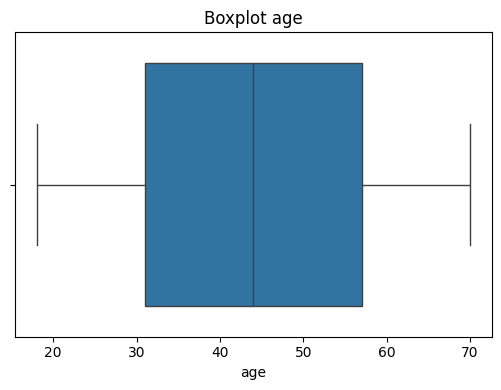

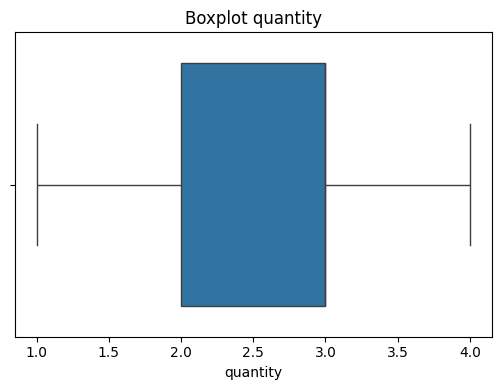

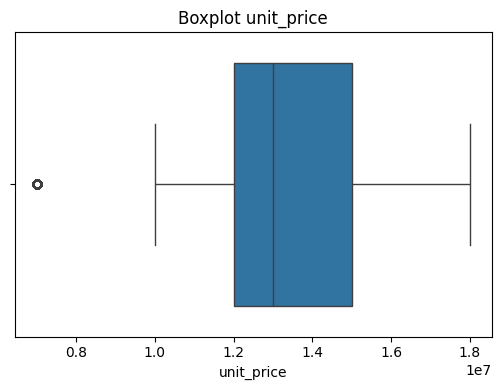

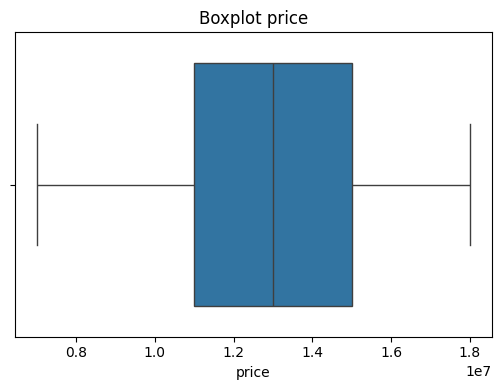

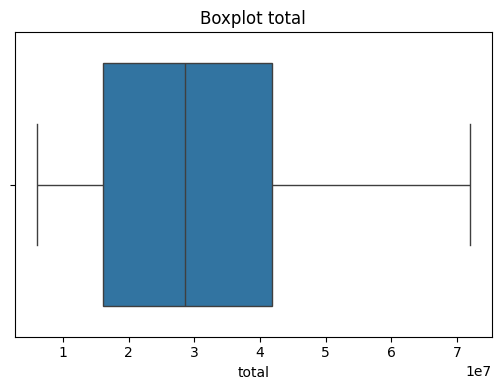

In [ ]:
# Kolom numerik yang ingin dianalisis
cols = ['age', 'quantity', 'unit_price', 'price', 'total']
data = df[cols]

# Loop untuk boxplot
for col in cols:
    plt.figure(figsize=(15, 4))

    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()

### Menangani Missing Value

In [ ]:
df.isna().sum()

,0
transaction_id,0
transaction_date,0
customer_id,0
name,0
age,0
city,0
product_id,0
product_name,0
storage,0
color,0


In [ ]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
customer_id,0
name,0
age,0
city,0
product_id,0
product_name,0
storage,0
color,0


In [ ]:
df['coupon_code'].unique()

array([nan, 'DISCOUNT10', 'GRATISONGKIR', 'SALE20'], dtype=object)

In [ ]:
df['coupon_code'].fillna('NONKUPON', inplace=True)

/tmp/ipython-input-371169892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['coupon_code'].fillna('NONKUPON', inplace=True)


In [ ]:
df['coupon_code'].unique()

array(['NONKUPON', 'DISCOUNT10', 'GRATISONGKIR', 'SALE20'], dtype=object)

### Menghapus Data Harga Abnormal

In [ ]:
df['selisih_harga'] = df['unit_price'] - df['price']

def classify_price(row):
    selisih = row['selisih_harga']
    if selisih == 0:
        return 'Normal'
    elif 0 >= selisih >= -4000000:
        return 'Normal Di Bawah'
    elif 0 <= selisih <= 3000000:
        return 'Normal Di Atas'
    else:
        return 'Abnormal'

df['keterangan_harga'] = df.apply(classify_price, axis=1)

In [ ]:
df.head()

,transaction_id,transaction_date,customer_id,name,age,city,product_id,product_name,storage,color,shipping_method,payment_method,quantity,unit_price,price,coupon_code,discount,total,selisih_harga,keterangan_harga
0,25218,2024-11-04,24138,Kiandra Siregar,25,Yogyakarta,12,iPhone 13 Pro Max,512GB,Space Gray,POS Indonesia,GoPay,3,7000000,15000000,NONKUPON,15,17850000.0,-8000000,Abnormal
1,78866,2023-06-05,39458,Juli Zulkarnain,54,Jakarta,9,iPhone SE (3rd Gen),64GB,White,GrabExpress,GoPay,1,15000000,7000000,DISCOUNT10,15,12750000.0,8000000,Abnormal
2,71024,2024-01-28,36119,Kamila Irawan,45,Jakarta,1,iPhone 15,128GB,Black,POS Indonesia,GoPay,3,11000000,12000000,DISCOUNT10,15,28050000.0,-1000000,Normal Di Bawah
3,45980,2024-05-13,21642,Wirda Kusumo,23,Makassar,6,iPhone 14 Plus,256GB,Green,GoSend,Cash on Delivery,4,12000000,12000000,DISCOUNT10,15,40800000.0,0,Normal
4,35845,2024-09-19,28348,Tgk. Yuni Suryono,19,Yogyakarta,4,iPhone 15 Pro Max,1TB,Gold,POS Indonesia,GoPay,3,17000000,18000000,NONKUPON,15,43350000.0,-1000000,Normal Di Bawah


In [ ]:
# Jumlah data dengan keterangan "Abnormal"
abnormal_count = df["keterangan_harga"].value_counts().get("Abnormal", 0)
print("Jumlah data Abnormal:", abnormal_count)

Jumlah data Abnormal: 73560


In [ ]:
# Jumlah total data
total_data = len(df)
print("Jumlah total data:", total_data)

Jumlah total data: 199810


**Untuk menghindari ketidaksesuaian harga dan potensi kesalahan analisis, data dengan keterangan harga 'Abnormal' dihapus dari dataset.**

In [ ]:
df = df[df['keterangan_harga'] != 'Abnormal'].copy()

In [ ]:
df["keterangan_harga"].value_counts()

,count
keterangan_harga,
Normal Di Bawah,55559
Normal Di Atas,45779
Normal,24912


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126250 entries, 2 to 199998
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    126250 non-null  int64  
 1   transaction_date  126250 non-null  object 
 2   customer_id       126250 non-null  int64  
 3   name              126250 non-null  object 
 4   age               126250 non-null  int64  
 5   city              126250 non-null  object 
 6   product_id        126250 non-null  int64  
 7   product_name      126250 non-null  object 
 8   storage           126250 non-null  object 
 9   color             126250 non-null  object 
 10  shipping_method   126250 non-null  object 
 11  payment_method    126250 non-null  object 
 12  quantity          126250 non-null  int64  
 13  unit_price        126250 non-null  int64  
 14  price             126250 non-null  int64  
 15  coupon_code       126250 non-null  object 
 16  discount          126250 

In [ ]:
df['customer_id'].nunique()

38055

### Kategori Umur

In [ ]:
usia_bins = [17, 25, 35, 45, 55, 65, df['age'].max()]
usia_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['usia_group'] = pd.cut(df['age'], bins=usia_bins, labels=usia_labels)

In [ ]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df[df['transaction_date'].dt.year != 2021].copy()

## Exploratory Data Analysis (EDA)


In [ ]:
# Setup visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Frekuensi Transaksi per Bulan

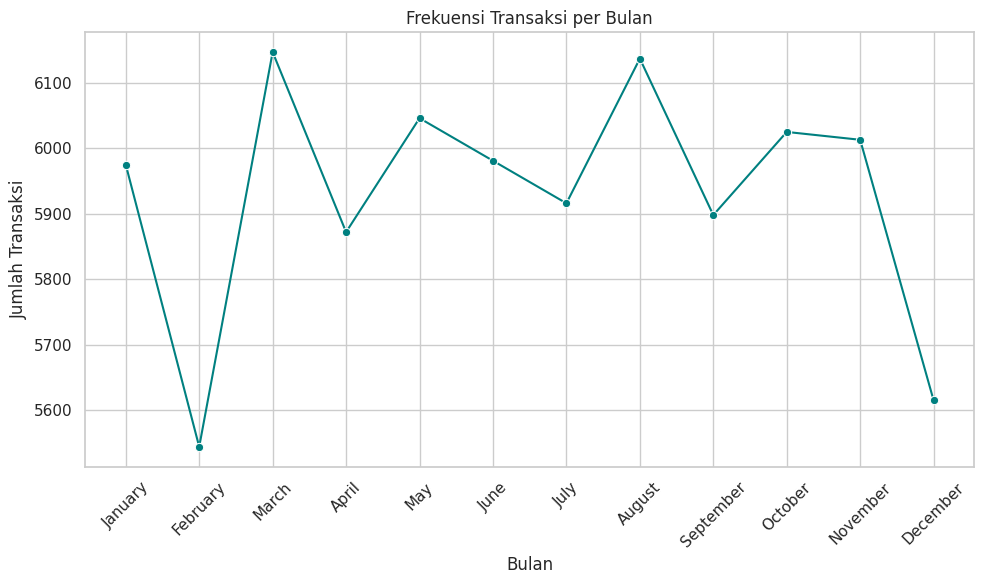

In [ ]:
import calendar
monthly_freq = (
    df.groupby(df['transaction_date'].dt.month)['transaction_id']
    .nunique()
    .reindex(range(1, 13), fill_value=0)
    .reset_index()
)
monthly_freq.columns = ['month', 'count']
monthly_freq['month_name'] = monthly_freq['month'].apply(lambda x: calendar.month_name[x])

plt.figure()
sns.lineplot(data=monthly_freq, x='month_name', y='count', marker='o', color='teal')
plt.title("Frekuensi Transaksi per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Frekuensi transaksi meningkat pada bulan tertentu (kemungkinan bertepatan dengan promo atau musim liburan).

### Distribusi Metode Pembayaran

/tmp/ipython-input-1372681719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='payment_method', palette='Set2', order=df['payment_method'].value_counts().index)


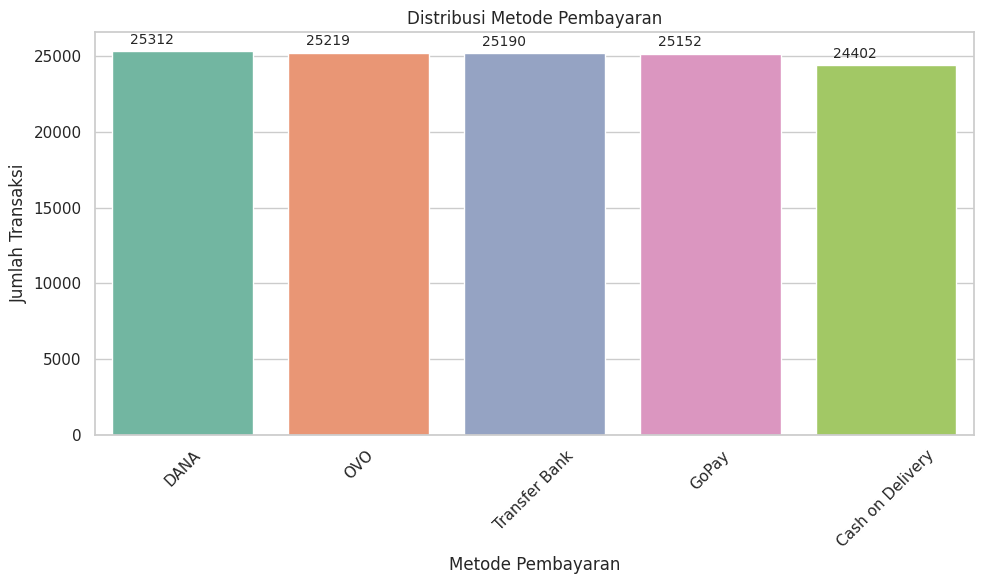

In [ ]:
plt.figure()
ax = sns.countplot(data=df, x='payment_method', palette='Set2', order=df['payment_method'].value_counts().index)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.1, p.get_height() + 500), fontsize=10)
plt.title("Distribusi Metode Pembayaran")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Metode pembayaran paling banyak digunakan adalah Dana, namun distribusinya cukup berimbang antara Dana, Ovo, Gopay, dan Transfer Bank, menandakan pelanggan memiliki preferensi yang bervariasi dan cenderung nyaman dengan berbagai opsi pembayaran digital maupun konvensional.

### Distribusi Total Pembayaran

/tmp/ipython-input-3902500011.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=total_group_temp, palette='coolwarm', order=labels)


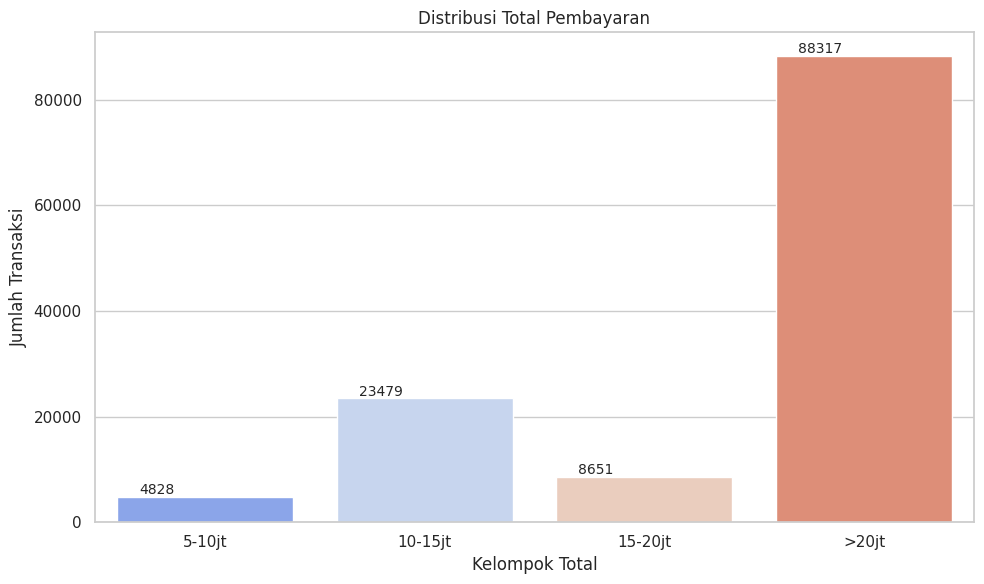

In [ ]:
# Buat kategori sementara tanpa menambah kolom ke df
bins = [5000000, 10000000, 15000000, 20000000, df['total'].max()]
labels = ['5-10jt', '10-15jt', '15-20jt', '>20jt']
total_group_temp = pd.cut(df['total'], bins=bins, labels=labels, include_lowest=True)

# Visualisasi
plt.figure()
ax = sns.countplot(x=total_group_temp, palette='coolwarm', order=labels)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.1, p.get_height() + 500), fontsize=10)
plt.title("Distribusi Total Pembayaran")
plt.xlabel("Kelompok Total")
plt.ylabel("Jumlah Transaksi")
plt.tight_layout()
plt.show()

Total pembayaran terbanyak berada di kisaran >20 juta. Nilai ini tidak selalu mencerminkan harga satu unit iPhone, melainkan bisa berasal dari pembelian lebih dari satu unit sekaligus atau kombinasi beberapa produk dalam satu transaksi.

### Jumlah Transaksi per Kota

/tmp/ipython-input-1727901776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='city', palette='Set1', order=df['city'].value_counts().index)


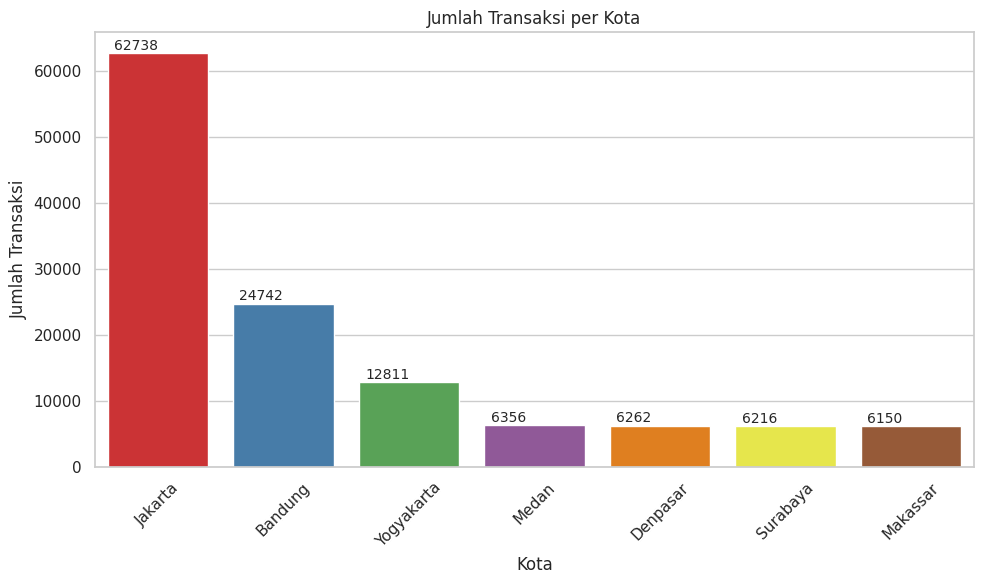

In [ ]:
plt.figure()
ax = sns.countplot(data=df, x='city', palette='Set1', order=df['city'].value_counts().index)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.05, p.get_height() + 500), fontsize=10)
plt.title("Jumlah Transaksi per Kota")
plt.xlabel("Kota")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Kota Jakarta dengan transaksi tertinggi menunjukkan wilayah pasar potensial yang harus menjadi prioritas distribusi.

### Distribusi Usia Pelanggan

/tmp/ipython-input-613042257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='usia_group', palette='mako')


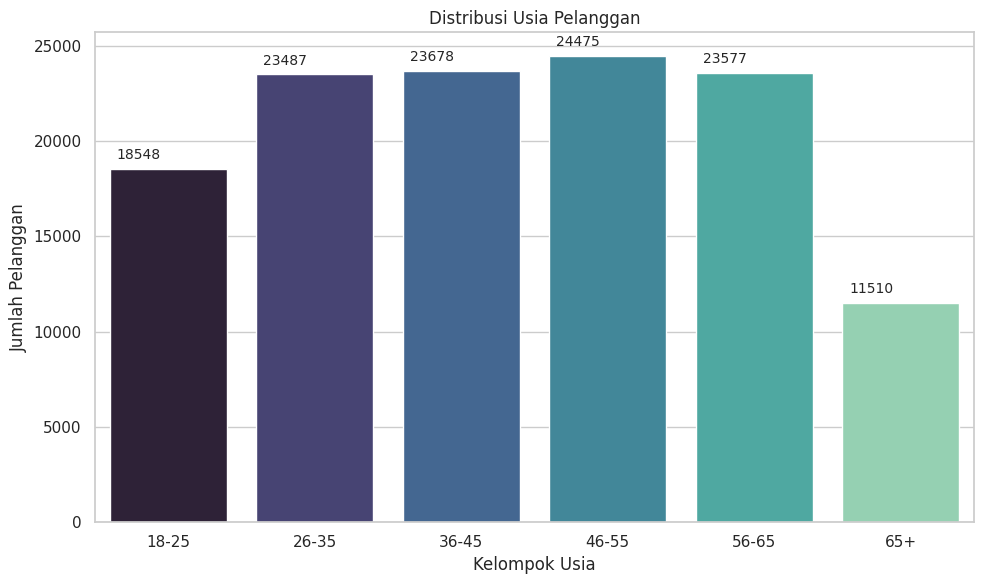

In [ ]:
plt.figure()
ax = sns.countplot(data=df, x='usia_group', palette='mako')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.05, p.get_height() + 500), fontsize=10)
plt.title("Distribusi Usia Pelanggan")
plt.xlabel("Kelompok Usia")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

Pelanggan didominasi usia 46-55 tahun, segmen ini adalah target utama untuk pemasaran produk premium.

Warna populer cenderung warna netral seperti silver, menunjukkan preferensi pelanggan pada desain elegan dan klasik yang cocok untuk berbagai segmen.

In [ ]:
df.head()

,transaction_id,transaction_date,customer_id,name,age,city,product_id,product_name,storage,color,shipping_method,payment_method,quantity,unit_price,price,coupon_code,discount,total,selisih_harga,keterangan_harga,usia_group
2,71024,2024-01-28,36119,Kamila Irawan,45,Jakarta,1,iPhone 15,128GB,Black,POS Indonesia,GoPay,3,11000000,12000000,DISCOUNT10,15,28050000.0,-1000000,Normal Di Bawah,36-45
3,45980,2024-05-13,21642,Wirda Kusumo,23,Makassar,6,iPhone 14 Plus,256GB,Green,GoSend,Cash on Delivery,4,12000000,12000000,DISCOUNT10,15,40800000.0,0,Normal,18-25
4,35845,2024-09-19,28348,Tgk. Yuni Suryono,19,Yogyakarta,4,iPhone 15 Pro Max,1TB,Gold,POS Indonesia,GoPay,3,17000000,18000000,NONKUPON,15,43350000.0,-1000000,Normal Di Bawah,18-25
6,49723,2024-04-15,36190,Digdaya Gunarto,27,Bandung,8,iPhone 14 Pro Max,128GB,Yellow,JNE,Cash on Delivery,4,13000000,17000000,GRATISONGKIR,5,49400000.0,-4000000,Normal Di Bawah,26-35
8,55065,2023-01-04,36596,Tgk. Zulaikha Setiawan,56,Bandung,3,iPhone 15 Pro,512GB,Silver,POS Indonesia,OVO,4,15000000,16000000,SALE20,10,54000000.0,-1000000,Normal Di Bawah,56-65


In [ ]:
df.to_csv("data_final.csv", index=False)